# Running the IMAV Challenge DroNet CNN on the GAP9 SoC (in GVSoC Simulation)

## Imports

In [1]:
DIRECTORY_GENERATED_CODE = "./generated_code"

In [2]:
import sys, os
print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("AT_HOME:", os.environ.get("AT_HOME"))
print("PYTHONPATH:", os.environ.get("PYTHONPATH"))

Python: /home/lamberti/anaconda3/envs/gap_sdk_5.20.4/bin/python
CONDA_DEFAULT_ENV: gap_sdk_5.20.4
AT_HOME: /home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3
PYTHONPATH: /home/lamberti/gap/5.20.4/gap_sdk_private/utils/gapy_v2/bin:/home/lamberti/gap/5.20.4/gap_sdk_private/tools/audio-framework/python_tools:/home/lamberti/gap/5.20.4/gap_sdk_private/gvsoc/gvsoc/models/:/home/lamberti/gap/5.20.4/gap_sdk_private/gvsoc/gvsoc_gap:/home/lamberti/gap/5.20.4/gap_sdk_private/install/workstation/python:/home/lamberti/gap/5.20.4/gap_sdk_private/utils/:/home/lamberti/gap/5.20.4/gap_sdk_private/tools/nntool:


In [3]:
# NNTool Imports
import sys
sys.path.append("/home/lamberti/gap/5.20.4/gap_sdk_private/tools/nntool/")  # where nntool lives

from nntool.api import NNGraph
from nntool.api.utils import quantization_options, model_settings
from tqdm import tqdm
from glob import glob
from PIL import Image
import numpy as np

In [4]:
# IMAV Imports
import os
import sys
import numpy as np

from matplotlib import pyplot as plt
# %matplotlib inline      # must be done before matplotlib import
# %matplotlib notebook  # must be done before matplotlib import

# images
import cv2
import imgaug.augmenters as iaa
#Pillow
from PIL import Image as Image
from IPython.display import display as display
# WAND
# from wand.image import Image as WImage
# from wand.display import display as Wdisplay

In [5]:
# Dronet Imports
sys.path.append('./') # needed for models and utility
# from cnn import dronet_imav, ResBlock, dronet
import cnn
# from augmentation import ImgAugTransform, Brightness


In [6]:
# Other Imports
import torch
import torch.nn as nn
from torchvision import datasets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import importlib

2026-05-22 15:27:03.304661: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 15:27:03.314638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779456423.326431 1605138 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779456423.329919 1605138 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-22 15:27:03.342829: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## IMAV CNN

### Arguments

In [49]:
args = {
    'model_weights_imav': 'pre-trained/imav_weights.pth',
    'model_weights_imav_onnx': 'pre-trained/imav_weights.onnx',
    'data_path_HM0360': './dataset/HM0360/',
    'data_path_HM01B0': './dataset/HM01B0/',
}

IMAGE_SIZE_162x162 = True
AUGMENTATION = False
MORE_BRIGHTNESS = False

# Bayer demosaicing: set True when images come from a raw Bayer-pattern sensor
# (e.g. Himax HM0360 in RAW8 mode).
# pattern: 'BG'=BGGR  'RG'=RGGB  'GB'=GBRG  'GR'=GRBG
DEBAYER = True
DEBAYER_PATTERN = 'BG'  # BGGR — standard for Himax HM0360


### Data

##### Augmentation

In [50]:
class DebayerTransform:
    """Demosaic a raw Bayer-pattern grayscale image to a proper grayscale image.
    Uses OpenCV bilinear interpolation; preserves full resolution.
    pattern: 'BG'=BGGR, 'RG'=RGGB, 'GB'=GBRG, 'GR'=GRBG
    """
    _codes = {
        'BG': cv2.COLOR_BayerBG2GRAY,
        'GB': cv2.COLOR_BayerGB2GRAY,
        'RG': cv2.COLOR_BayerRG2GRAY,
        'GR': cv2.COLOR_BayerGR2GRAY,
    }
    def __init__(self, pattern='BG'):
        self.code = self._codes[pattern]
    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("L"))  # force single-channel; ImageFolder loads as RGB
        gray = cv2.cvtColor(arr, self.code)
        return Image.fromarray(gray)

    
def debayer_bggr_green_only(raw: np.ndarray) -> np.ndarray:
  """
  Simplified demosaic: output the G channel at full resolution.

  G pixels (where (r+c)%2==1) are used directly.
  B/R pixels (where (r+c)%2==0) are replaced by the average of their
  4 orthogonal G neighbors.

  No multiplications, no BT.601 weighting.
  Error vs full bilinear: mean ~10 gray levels on HM0360 data.
  """
  H, W = raw.shape
  img = raw.astype(np.int32)
  out = np.empty((H, W), dtype=np.uint8)

  for r in range(H):
      r0 = r - 1 if r > 0 else 0
      r1 = r + 1 if r < H - 1 else H - 1
      for c in range(W):
          if (r + c) % 2 == 1:                  # G pixel — use directly
              out[r, c] = raw[r, c]
          else:                                   # B or R — average 4 G neighbors
              c0 = c - 1 if c > 0 else 0
              c1 = c + 1 if c < W - 1 else W - 1
              out[r, c] = (img[r0, c] + img[r1, c] + img[r, c0] + img[r, c1]) >> 2
  return out


class DebayerTransformGreenOnly:
    """Simplified drop-in for DebayerTransform. Suitable for MCU prototyping."""
    def __call__(self, pil_img: Image.Image) -> Image.Image:
      raw = np.array(pil_img.convert("L"))
      gray = debayer_bggr_green_only(raw)
      return Image.fromarray(gray)



import torchvision.transforms.functional as TF
crop_size = 162
cx, cy = 100, 120  # custom center: x, y

def crop_around_center(img):
    left = int(cx - crop_size / 2)
    top = int(cy - crop_size / 2)
    return TF.crop(img, top=top, left=left, height=crop_size, width=crop_size)


class Brightness:
    def __init__(self, brightness_factor=1.):
        self.brightness_factor = brightness_factor
    def __call__(self, image):
        image = transforms.functional.adjust_brightness(image, self.brightness_factor)
        # image.save('debug.png')
        return image

        
def get_transformations(crop=False, crop_custom=False, debayer=False, brightness=False, debayer_pattern='BG'):
    transf_list = []
    print("Transformations:")

    if debayer:
        print(f"\t- DEBAYER ACTIVE (Bayer {debayer_pattern} -> grayscale)")
        # transf_list += [DebayerTransform(pattern=debayer_pattern)]
        transf_list += [DebayerTransformGreenOnly()]

    if AUGMENTATION == True:
        transf_list += [ImgAugTransform()]

    if brightness:
        print("\t- MORE BRIGHTNESS ACTIVE")
        transf_list += [Brightness(brightness_factor=0.5)]

    if crop:
        print("\t- CROPPING ACTIVE")
        transf_list += [transforms.CenterCrop(162)]
        
    if crop_custom:
        print("\t- CROPPING custom ACTIVE")
        transf_list += [transforms.Lambda(crop_around_center)]

        
    else:
        size = (162, 162)
        print("\t- RESIZE TO:", size)
        transf_list += [transforms.Resize(size)]

    transf_list += [
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()
    ]
    transformations = transforms.Compose(transf_list)
    return transformations


##### Images / Datasets

In [51]:
class ImageFolderWithPaths(datasets.ImageFolder):
    """Custom dataset that includes image file paths. Extends
    torchvision.datasets.ImageFolder
    """
    # override the __getitem__ method. this is the method that dataloader calls
    def __getitem__(self, index):
        # this is what ImageFolder normally returns
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        # the image file path
        path = self.imgs[index][0]
        # make a new tuple that includes original and the path
        tuple_with_path = (original_tuple + (path,))
        return tuple_with_path

In [52]:
class CustomGAPDataLoader():
    """
    Based on MyDataLoader example from NNTool API reference on collecting
    statistics for quantization.
    """

    def __init__(self, image_files, max_idx=None, transpose_to_chw=False, transpose_to_hwc=False):
        self._file_list = image_files
        self._idx = 0
        self._max_idx = max_idx if max_idx is not None else len(image_files)
        self._transpose_to_chw = transpose_to_chw
        self._transpose_to_hwc = transpose_to_hwc

    def __iter__(self):
        self._idx = 0
        return self

    def __next__(self):
        if self._idx >= self._max_idx:
            raise StopIteration()
        tuple_with_path = self._file_list[self._idx]

        # Image needs to be a np.array. As a torch.tensor it won't work with NNTools
        # quantization tool
        img_array = np.array(tuple_with_path[0])

        # Transpose to CHW or HWC
        if self._transpose_to_chw:
            img_array = img_array.transpose(2, 0, 1)

        elif self._transpose_to_hwc:
            img_array = img_array.transpose(1, 2, 0)

        self._idx += 1
        return img_array

In [53]:
transformations_imav = get_transformations(crop=True, brightness=False, debayer=DEBAYER, debayer_pattern=DEBAYER_PATTERN)
dataset_HM0360 = ImageFolderWithPaths(args['data_path_HM0360'], transformations_imav)
dataloader_HM0360 = CustomGAPDataLoader(dataset_HM0360)

transformations_imav = get_transformations(crop=False)
dataset_HM01B0 = ImageFolderWithPaths(args['data_path_HM01B0'], transformations_imav)
dataloader_HM01B0 = CustomGAPDataLoader(dataset_HM01B0)

dataset = dataset_HM0360
dataloader = dataloader_HM0360


Transformations:
	- DEBAYER ACTIVE (Bayer BG -> grayscale)
	- CROPPING ACTIVE
	- RESIZE TO: (162, 162)
Transformations:
	- RESIZE TO: (162, 162)


### Pretrained IMAV Model

In [54]:
def load_weights(net, model_weights, device='cuda:0', verbose=False):
    # load previous weights
    if os.path.isfile(model_weights):
        if torch.cuda.is_available():
            checkpoint = torch.load(model_weights, map_location=device)
            print('loaded checkpoint on cuda')
        else:
            checkpoint = torch.load(model_weights, map_location='cpu')
            print('CUDA not available: loaded checkpoint on cpu')
        if 'state_dict' in checkpoint:
            checkpoint = checkpoint['state_dict']
        else:
            print('Warning: failed to find the [''state_dict''] inside the checkpoint. you probably are not providing a full checkpoint. I will try to open it anyways.')
        net.load_state_dict(checkpoint)
        print('Loaded state_dict inside network. Enjoy!')

    else:
        raise RuntimeError('Failed to open checkpoint. provide a checkpoint.pth.tar file')
    net.to(device)
    if verbose: summary(net, input_size=(1, 1, 324, 324))
    return net

In [55]:
# Get image size and define stride stages
image_size = list(np.squeeze(next(iter(dataset))[0]).shape)
print(f"Input image size: {image_size} pixels")
stride=[2,2,2,2,2]
if IMAGE_SIZE_162x162:
    fc_in_size=[5,5]
else:
    fc_in_size=[11,11]

Input image size: [162, 162] pixels


In [56]:
importlib.reload(cnn) # In case changes were made to the model description after loading it in notebook

net_imav = cnn.dronet_imav(depth_mult=1., stride=stride, image_size=image_size, fc_in_size=fc_in_size, block_class=cnn.ResBlock, outputs=7)
net_imav = load_weights(net_imav, args['model_weights_imav'], device=device, verbose=False)
net_imav.eval()

CUDA not available: loaded checkpoint on cpu
Loaded state_dict inside network. Enjoy!


dronet_imav(
  (first_conv): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU6()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (resBlock1): ResBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU6()
    (relu2): ReLU6()
    (bypass): Conv2d(32, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (bn_bypass): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu3): ReLU6()
  )
  (resBlock2): ResBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3),

## NNTool

### Importing the ONNX Model

If onnx version of the model is not yet generated, you can generate it from pytorch version

In [57]:
def export_to_onnx(dataloader):
    dummy_input = next(iter(dataloader))
    print(f'Original image shape: {dummy_input.shape}')
    dummy_input = torch.unsqueeze(torch.tensor(dummy_input), dim=0)
    print(f'Unsqueezed image shape: {dummy_input.shape}')
    net_imav.eval()
    torch.onnx.export(net_imav, dummy_input, args['model_weights_imav_onnx'], opset_version=11)
    print(f"ONNX exported to: {args['model_weights_imav_onnx']}")

export_to_onnx(dataloader)

Original image shape: (1, 162, 162)
Unsqueezed image shape: torch.Size([1, 1, 162, 162])
ONNX exported to: pre-trained/imav_weights.onnx


In [58]:
# Patch NNTool's RemoveNoOPs to handle dangling nodes (nodes with 0 output edges).
# NNTool bug: when an earlier matcher creates reshape nodes that end up with no consumers,
# remove_noops asserts len(out_edges)==1 and crashes.  This in-memory patch skips them.
import nntool.graph.matches.matchers.remove_noops as _rn_mod
from nntool.graph.types import NNEdge, ReshapeNode as _ReshapeNode
import logging as _log

_orig_rn = _rn_mod.RemoveNoOPs._match

def _patched_rn(self, G, **kwargs):
    has_modified_graph = False
    for node in [n for n in G.nodes() if n.does_nothing(G)]:
        has_modified_graph = True
        in_edges  = G.indexed_in_edges(node.name)
        out_edges = G.indexed_out_edges(node.name)
        assert len(in_edges) == 1
        if len(out_edges) == 0:          # dead node — no consumers, just drop it
            G.remove_edge(in_edges[0])
            G.remove(node)
            continue
        assert len(out_edges) == 1
        in_edge   = in_edges[0]
        out_edges = out_edges[0]
        G.remove_edge(in_edge)
        if node.in_dims[0].shape != node.out_dims[0].shape:
            last_node = _ReshapeNode(
                G.unique_name(f'{node.name}_reshape'),
                old_shape=node.in_dims[0].shape,
                shape=node.out_dims[0].shape)
            G.add_edge(in_edge.clone(to_node=last_node, to_idx=0))
            last_idx = 0
        else:
            last_node = in_edge.from_node
            last_idx  = in_edge.from_idx
        for out_edge in G.out_edges(node.name):
            G.remove_edge(out_edge)
            G.add_edge(NNEdge(from_node=last_node, to_node=out_edge.to_node,
                              from_idx=last_idx, to_idx=out_edge.to_idx))
        G.remove(node)
    return has_modified_graph

_rn_mod.RemoveNoOPs._match = _patched_rn
print("RemoveNoOPs patched: dangling nodes will be silently removed")


RemoveNoOPs patched: dangling nodes will be silently removed


In [59]:
G = NNGraph.load_graph(args['model_weights_imav_onnx']) # TODO warning for padding

G.adjust_order()
G.fusions("scaled_match_group")

get_output_size: _first_conv_Conv has a padding setting not to SAME but in reality it is, changing the original padding from (2, 2)x(2, 2) to (2, 1)x(2, 1)
get_output_size: _resBlock1_conv1_Conv has a padding setting not to SAME but in reality it is, changing the original padding from (1, 1)x(1, 1) to (1, 0)x(1, 0)
get_output_size: _resBlock2_conv1_Conv has a padding setting not to SAME but in reality it is, changing the original padding from (1, 1)x(1, 1) to (1, 0)x(1, 0)
get_output_size: _resBlock3_conv1_Conv has a padding setting not to SAME but in reality it is, changing the original padding from (1, 1)x(1, 1) to (1, 0)x(1, 0)


In [60]:
# G.draw()
print(G.show())

+------+-------------------+------------------+-------------+-------------+--------+--------+--------+---------+------------------+------------------+
| Step |     Step name     |    Operation     | Input Dims  | Output Dims | Inputs | Active | Params |   Ops   |      Params      |      Hints       |
|      |                   |                  |  (0x1x2x3)  |  (0x1x2x3)  |        |  size  |  size  |         |                  |                  |
+======+===================+==================+=============+=============+========+========+========+=========+==================+==================+
|  0   | input_1           | input            | 1x1x162x162 | 1x1x162x162 |        | 26244  |   0    |         | I 1x1x162x162    | in: none out:    |
|      |                   |                  |             |             |        |        |        |         |                  | none             |
+------+-------------------+------------------+-------------+-------------+--------+--------+-

### Quantization

In [61]:
# from nntool.api.utils import RandomIter
# stats_fake = G.collect_statistics(RandomIter.fake(G))

In [62]:
dummy_input = next(iter(dataloader))
print(f'Original image shape: {dummy_input.shape}')
print(f'min: {np.min(dummy_input)}, max: {np.max(dummy_input)}')

Original image shape: (1, 162, 162)
min: 0.15294118225574493, max: 1.0


In [63]:
dataloader = CustomGAPDataLoader(dataset_HM0360)  # fresh iterator for collect_statistics


In [64]:
stats = G.collect_statistics(dataloader, progress=True)


11it [00:02,  5.25it/s]


In [65]:
G.quantize(
    stats,
    # When using the NE16 neural engine, HWC is used inside that engine.
    # NNTool automatically transforms the layers in the graph to HWC if necessary
    # in this quantization step.
    # Therefore it makes sense to activate the HWC kernels as well (`hwc=True`).
    graph_options=quantization_options(
        weight_bits=8,
        use_ne16=True,
        hwc=True,
        allow_asymmetric_out=True
        
    ),
)

In [66]:
# G.draw()
# print(G.show())

In [67]:
  def print_quantization_ranges(G):
      from nntool.graph.types import InputNode, OutputNode
      print(f"{'Node':>6}  {'Name':<30}  {'dtype':>6}  {'zp':>4}  {'scale':>10}  "
            f"{'int_min→float':>18}  {'int 0→float':>14}  {'int_max→float':>18}")
      print("-" * 105)
      for i, node in enumerate(G.nodes()):
          if not isinstance(node, (InputNode, OutputNode)):
              continue
          qrec = G.quantization.get(node.name)
          if not qrec:
              continue
          qs = qrec.out_qs or qrec.in_qs
          for q in (qs or []):
              signed  = q.signed
              zp      = int(q.zero_point.flat[0])
              sc      = float(q.scale.flat[0])
              imin    = -128 if signed else 0
              imax    =  127 if signed else 255
              dtype   = 'int8' if signed else 'uint8'
              print(f"[{i:3}]  {node.name:<30}  {dtype:>6}  {zp:>4}  {sc:>10.6f}  "
                    f"  int {imin:4d} → {(imin-zp)*sc:+.4f}  "
                    f"  int   0 → {(0-zp)*sc:+.4f}  "
                    f"  int {imax:3d} → {(imax-zp)*sc:+.4f}")

  print_quantization_ranges(G)

  Node  Name                             dtype    zp       scale       int_min→float     int 0→float       int_max→float
---------------------------------------------------------------------------------------------------------
[  0]  input_1                          uint8     0    0.003922    int    0 → +0.0000    int   0 → +0.0000    int 255 → +1.0000
[  1]  output_1                          int8     0    0.000031    int -128 → -0.0039    int   0 → +0.0000    int 127 → +0.0039
[  2]  output_2                         uint8   128    0.049134    int    0 → -6.2891    int   0 → -6.2891    int 255 → +6.2400
[  3]  output_3                         uint8     0    0.003922    int    0 → +0.0000    int   0 → +0.0000    int 255 → +1.0000


### Test Accurary

In [68]:
def inference_torch(image, net, verbose=False):
    net.eval()
    if verbose: print('size tensor:\t', image.shape)
    image = torch.unsqueeze(image, dim=0)
    if verbose: print('size tensor unsqueezed:\t', image.shape, end="\n\n")
    with torch.no_grad():
        output= net(image)
    return output

In [80]:
def get_output_idxs(G):
    """Return step indices of OutputNode objects: [edge, yaw, pcoll]."""
    from nntool.graph.types import OutputNode
    return [i for i in range(len(G)) if isinstance(G[i], OutputNode)]


def print_outputs(outputs, model_quantized=False, precision=2):
    if not model_quantized:
        edge_output      = outputs[0].cpu().detach().numpy() # not used
        yaw_output       = outputs[1].cpu().detach().numpy() # not used
        collision_output = outputs[2].cpu().detach().numpy().squeeze()
    else:
        edge_output      = outputs[-13][0]
        yaw_output       = outputs[-10][0]
        collision_output = outputs[-1][0][0]

    print('Edge:', np.round(edge_output,precision), end="\t")
    print('Yaw:', np.round(yaw_output,precision), end="\t")
    print('Collision:', np.round(collision_output,precision), end="\n\n")
    return collision_output
out_idxs = get_output_idxs(G)  # [edge_step, yaw_step, pcoll_step]


In [70]:
def view_image(image, save=True, save_path='./', verbose=True):
    if verbose: print('size image:\t', image.shape)
#     if save: cv2.imwrite(save_path, image)

    image_array = image.squeeze().numpy()*255
    if verbose: print('size array:\t', image_array.shape)

    ### OPENCV ###
    if save: cv2.imwrite(save_path, image_array)
    plt.imshow(image_array,cmap='gray')
    plt.show()

    #### PILLOW ####
#     pil_img = Image.fromarray(image_array, 'L')
#     pil_img.show()
#     display(pil_img)     #PILLOW
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converting BGR to RGB
#     display(Image.fromarray(img))


In [71]:
iter_dataloader = iter(dataloader)  # superseded by cell below


In [ ]:
#dataloader = CustomGAPDataLoader(dataset_HM0360)  # reset after collect_statistics exhausted it
img_test = next(iter_dataloader)

float_execution = G.execute([img_test], quantize=False, dequantize=False)
edge_output      = float_execution[out_idxs[0]][0].squeeze()  # (3,) softmax
yaw_output       = float_execution[out_idxs[1]][0].squeeze()  # scalar
collision_output = float_execution[out_idxs[2]][0].squeeze()  # (3,) [pcoll_L, pcoll_C, pcoll_R]
print(f"float output\t\tEdge={np.round(edge_output,3)}  Yaw={float(yaw_output):.4f}  Collision={np.round(collision_output,3)}")

quant_execution = G.execute([img_test], quantize=True, dequantize=True)
edge_output      = quant_execution[out_idxs[0]][0].squeeze()
yaw_output       = quant_execution[out_idxs[1]][0].squeeze()
collision_output = quant_execution[out_idxs[2]][0].squeeze()
print(f"quant/dequant\t\tEdge={np.round(edge_output,3)}  Yaw={float(yaw_output):.4f}  Collision={np.round(collision_output,3)}")

int_execution = G.execute([img_test], quantize=True, dequantize=False)
edge_int      = int_execution[out_idxs[0]][0].squeeze()
yaw_int       = int_execution[out_idxs[1]][0].squeeze()
coll_int      = int_execution[out_idxs[2]][0].squeeze()
print(f"int output\t\tEdge={edge_int}  Yaw={yaw_int}  \tCollision={coll_int}")
print(f"image range:\t\tmin={np.min(img_test):.4f}  max={np.max(img_test):.4f}")

view_image(torch.tensor(img_test), save=False, save_path='./visualize_prediction/processed.png', verbose=True)


float output		Edge=[0.066 0.934 0.   ]  Yaw=-0.1278  Collision=[0.858 0.169 0.126]
quant/dequant		Edge=[0.06 0.94 0.  ]  Yaw=-0.1474  Collision=[0.863 0.157 0.125]
int output		Edge=[ 1968 30796     3]  Yaw=125  	Collision=[220  40  32]
image range:		min=0.1255  max=1.0000
size image:	 torch.Size([1, 162, 162])
size array:	 (162, 162)


In [31]:
from nntool.graph.types import ConstantInputNode
qsnrs_by_layer = G.qsnrs(float_execution, quant_execution)
print("QSNR layer by layer (skipping constant layers like weights and biases):")
print(f"{'Layer Name':>30} (  #): {'QSNR':4}")
for i, q in enumerate(qsnrs_by_layer):
    if isinstance(G[i], ConstantInputNode):
        continue
    print(f"{G[i].name:>30} ({i:3}): {q:4}")

QSNR layer by layer (skipping constant layers like weights and biases):
                    Layer Name (  #): QSNR
                       input_1 (  0):  150
   _first_conv_Conv_reshape_in (  1):  150
       _first_conv_Conv_fusion (  4):   41
  _resBlock1_conv1_Conv_fusion (  7):   38
  _resBlock1_conv2_Conv_fusion ( 10):   38
_resBlock1_conv2_Conv_reshape_out ( 11):   38
 _resBlock1_bypass_Conv_fusion ( 14):   35
_resBlock1_bypass_Conv_reshape_out ( 15):   35
                        expr_0 ( 16):   37
_resBlock2_conv1_Conv_reshape_in ( 17):   37
  _resBlock2_conv1_Conv_fusion ( 20):   37
  _resBlock2_conv2_Conv_fusion ( 23):   36
_resBlock2_conv2_Conv_reshape_out ( 24):   36
 _resBlock2_bypass_Conv_fusion ( 27):   34
_resBlock2_bypass_Conv_reshape_out ( 28):   34
                        expr_1 ( 29):   35
_resBlock3_conv1_Conv_reshape_in ( 30):   35
  _resBlock3_conv1_Conv_fusion ( 33):   33
  _resBlock3_conv2_Conv_fusion ( 36):   29
_resBlock3_conv2_Conv_reshape_out ( 37):   29
 _re

In [32]:
# img_test = next(test_dataloader)

# print("INPUT")
# outputs_orig = inference_torch(torch.tensor(img_test), net_imav, verbose=True)

# print("OUTPUT ORIGINAL TORCH MODEL")
# out_orig = print_outputs(outputs_orig, precision=4)

# print("OUTPUT QUANTIZED GAP MODEL")
# outputs_quant = G.execute(img_test, quantize=True, dequantize=True)
# out_quant = print_outputs(outputs_quant, model_quantized=True, precision=4)

# view_image(torch.tensor(img_test), save=False, save_path='./visualize_prediction/processed.png', verbose=True)

### Run on target
NNTool allows the user to directly get performance metrics of the platform directly from python APIs by generating a template project and run it.
NOTE: the "gap9_project" was generated by this command, and then changed to adapt in a real application.

In [33]:
# Inference on a single image to get quantized input and output tensors
qout = G.execute(img_test, quantize=True, dequantize=False)

print("input")
int_test = qout[0][0]
print(int_test)
int_test.shape

print("output")
print(qout[out_idxs[2]][0].squeeze())  # output_3 = collision (3,)

input
[[[[ 72  86  80 ... 111  98 109]
   [ 90  88  89 ... 109 107 101]
   [ 81  88  90 ... 109 109 112]
   ...
   [110 120 124 ... 128 125 120]
   [104 123 121 ... 129 128 131]
   [113 111 118 ... 120 128 112]]]]
output
[252 255 255]


In [34]:
# Autotiler options: make the autotiler allocate the input of the network and reuse that space after the first layer
# more L2 for the rest of the network
# G[0].at_options.allocate = 1
# G[0].at_options

In [35]:
directory = DIRECTORY_GENERATED_CODE
mkdir_cmd = f"mkdir -p {directory}"
os.system(mkdir_cmd)

res = G.execute_on_target(
    directory=directory,
    input_tensors=[int_test],
    cmake=True,
    write_out_to_file=True,
    # platform="board", # to run on the actual board
    platform="gvsoc", # to run on gvsoc simulator
    settings=model_settings(
        l1_size=128000,
        l2_size=1000000,
        tensor_directory='./tensors',
    ),   # most important argument that takes all the settings for AUTOTILE code generation
    at_loglevel=2,
    print_output=True,
)

Script started, output log file is '/tmp/tmp92qy9bul/log.txt'.
The target board you have sourced is : gap9_evk, GAP9_V2.
Release version: 5.20.4
-- Found Python: /home/lamberti/anaconda3/envs/gap_sdk_5.20.4/bin/python3.10 (found version "3.10.16") found components: Interpreter
-- [SDK] Version: 5.20.4
-- [Platform] GVSoC
-- [OS] FreeRTOS (Scheduler v2)
-- [Printf] Semihost
-- [Board] GAP Family : 9
-- [Board] GAP Version : 2
-- [AutoTiler] Setup model: imav_weights
-- Clock speeds - Cluster 370 FC 370 Peripheral 370
-- The C compiler identification is GNU 7.1.1
-- The ASM compiler identification is GNU
-- Found assembler: /home/lamberti/gap/5.20.4/gap_riscv_toolchain_ubuntu/install/bin/riscv32-unknown-elf-gcc
-- [Log] none

--- imav_weights options ---

-- [imav_weights] Include directories : /home/lamberti/work/temp/keanu/dronet_on_gap9/generated_code;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/Autotiler;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/Emu

In [36]:
import csv

def generate_performance_csv(performance_list: list, output_file: str):

    # Define the header row
    header = ["Layer", "Cycles", "Ops", "Ops/Cycle", "% Ops", "% Cycles"]

    with open(output_file, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(header)  # Write the header
        writer.writerows(performance_list)   # Write the data

    print(f"CSV data saved to {output_file}")

In [37]:
generate_performance_csv(res.performance, 'results/perf_imav_on_gap9_initial_on_hw_board_ne16.csv')

CSV data saved to results/perf_imav_on_gap9_initial_on_hw_board_ne16.csv


In [38]:
res.pretty_performance()

+-----------------------------------+---------+------------+-----------+---------+----------+
| Layer                             | Cycles  |    Ops     | Ops/Cycle |  % ops  | % cycles |
+===================================+=========+============+===========+=========+==========+
| S4__first_conv_Conv_fusion        | 423,590 |  5,453,600 |    12.875 |  22.035 |   51.910 |
+-----------------------------------+---------+------------+-----------+---------+----------+
| S7__resBlock1_conv1_Conv_fusion   |  74,451 |  3,686,400 |    49.514 |  14.895 |    9.124 |
+-----------------------------------+---------+------------+-----------+---------+----------+
| S10__resBlock1_conv2_Conv_fusion  |  37,143 |  3,686,400 |    99.249 |  14.895 |    4.552 |
+-----------------------------------+---------+------------+-----------+---------+----------+
| S14__resBlock1_bypass_Conv_fusion |  18,532 |    409,600 |    22.102 |   1.655 |    2.271 |
+-----------------------------------+---------+------------+

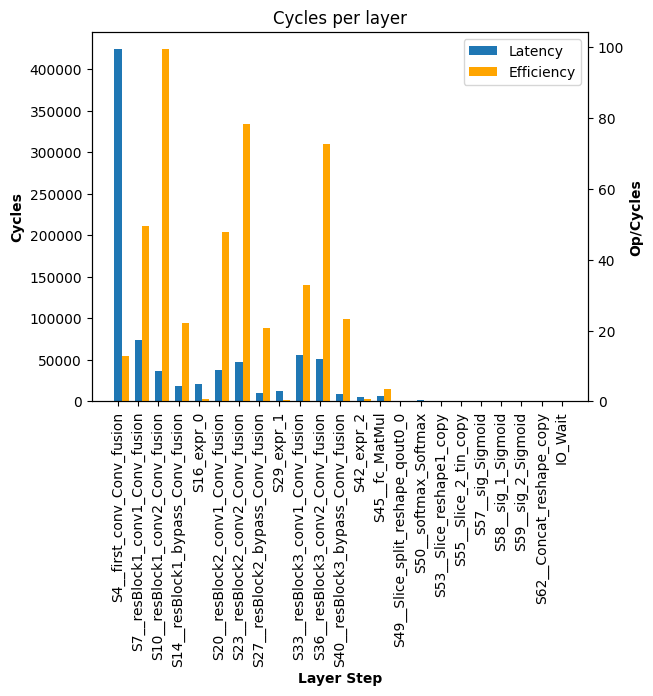

In [39]:
res.plot_performance();

No content found in the memory for this area L3


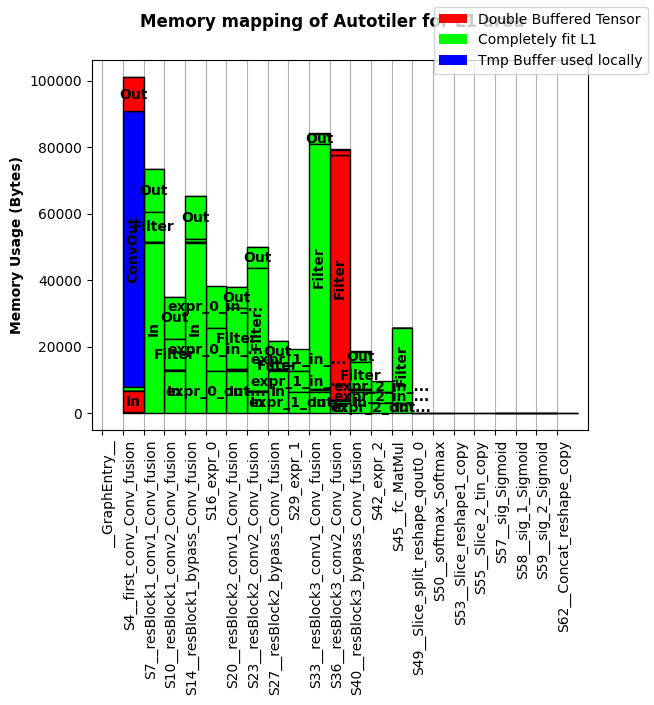

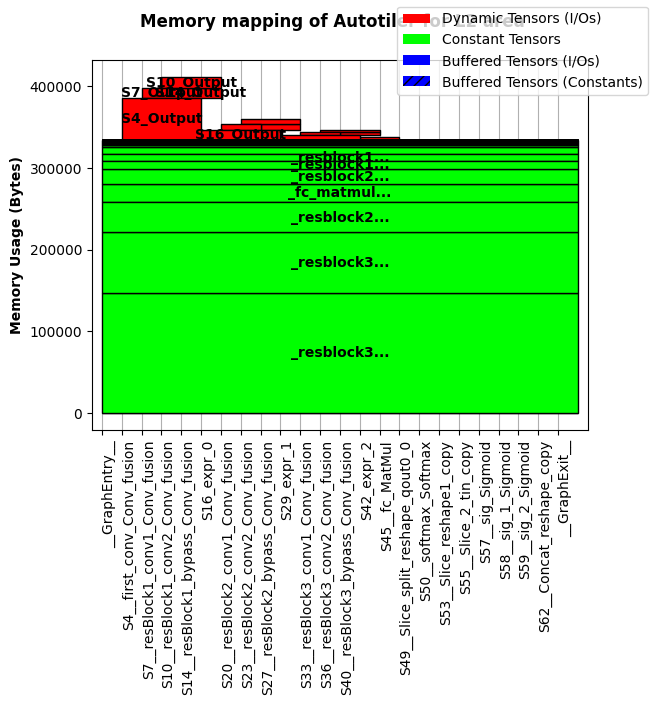

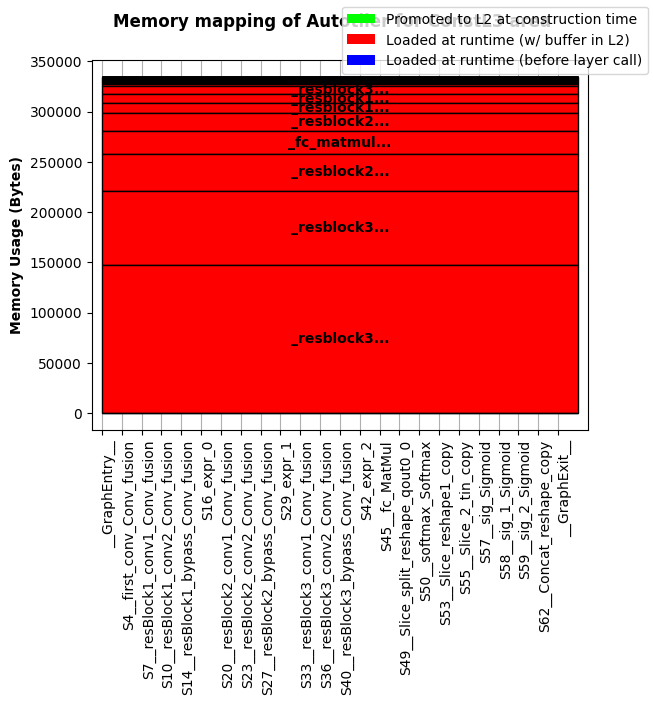

In [40]:
fig = res.plot_memory_boxes()

In [41]:
out_gap_1 = np.fromfile(directory + "/Output_1.bin", np.int16) # TODO Why does output #1 (edge) seem to be 16 bit quantized
out_gap_2 = np.fromfile(directory + "/Output_2.bin", np.uint8)
out_gap_3 = np.fromfile(directory + "/Output_3.bin", np.uint8)
in_gap_1 = np.fromfile(directory + "/Input_1.bin", np.uint8)

print(f"Inputs from Target:\n{in_gap_1}")
print(f"Outputs from Target:")

print('Edge:', out_gap_1, end="\t")
print('Yaw:', out_gap_2, end="\t")
print('Collision:', out_gap_3, end="\n\n")

Inputs from Target:
[ 72  86  80 ... 120 128 112]
Outputs from Target:
Edge: [14343 18416     8]	Yaw: [127]	Collision: [252 255 255]



In [42]:
print(f"Inputs from NNTool:\n{qout[0][0].flatten()}")

print(f"Outputs from NNTool:")
print('Edge:',      qout[out_idxs[0]][0].squeeze(), end="\t")
print('Yaw:',       qout[out_idxs[1]][0].squeeze(), end="\t")
print('Collision:', qout[out_idxs[2]][0].squeeze(), end="\n\n")


Inputs from NNTool:
[ 72  86  80 ... 120 128 112]
Outputs from NNTool:
Edge: [14343 18416     8]	Yaw: 127	Collision: [252 255 255]

